In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

import pickle

In [3]:
df = pd.read_csv("demand_forecasting.csv")

In [4]:
df

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75995,2024-01-30,S005,P0016,Toys,North,233,63,0,29.80,5,Snowy,0,32.23,Winter,0,64
75996,2024-01-30,S005,P0017,Toys,North,137,115,141,42.92,5,Snowy,0,40.73,Winter,0,137
75997,2024-01-30,S005,P0018,Clothing,North,197,44,0,17.81,10,Snowy,0,19.41,Winter,0,68
75998,2024-01-30,S005,P0019,Furniture,North,125,58,0,151.72,0,Snowy,0,143.71,Winter,0,84


In [5]:
features = [
    "Price",
    "Discount",
    "Inventory Level",
    "Promotion",
    "Competitor Pricing",
    "Category"
]

In [6]:
features

['Price',
 'Discount',
 'Inventory Level',
 'Promotion',
 'Competitor Pricing',
 'Category']

In [7]:
target = "Demand"

In [8]:
X = df[features].copy()

In [9]:
X

,Price,Discount,Inventory Level,Promotion,Competitor Pricing,Category
0,72.72,5,195,0,85.73,Electronics
1,80.16,15,117,1,92.02,Clothing
2,62.94,10,247,1,60.08,Clothing
3,87.63,10,139,0,85.19,Electronics
4,54.41,0,152,0,51.63,Groceries
...,...,...,...,...,...,...
75995,29.80,5,233,0,32.23,Toys
75996,42.92,5,137,0,40.73,Toys
75997,17.81,10,197,0,19.41,Clothing
75998,151.72,0,125,0,143.71,Furniture


In [10]:
y = df[target]

In [11]:
y

0        115
1        229
2        157
3         52
4         59
        ... 
75995     64
75996    137
75997     68
75998     84
75999     73
Name: Demand, Length: 76000, dtype: int64

In [12]:
label_encoders = {}
categorical_cols = X.select_dtypes(include="object").columns

In [13]:
categorical_cols

Index(['Category'], dtype='object')

In [14]:
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] =le

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42   # reproducibility
)

In [16]:
X

,Price,Discount,Inventory Level,Promotion,Competitor Pricing,Category
0,72.72,5,195,0,85.73,1
1,80.16,15,117,1,92.02,0
2,62.94,10,247,1,60.08,0
3,87.63,10,139,0,85.19,1
4,54.41,0,152,0,51.63,3
...,...,...,...,...,...,...
75995,29.80,5,233,0,32.23,4
75996,42.92,5,137,0,40.73,4
75997,17.81,10,197,0,19.41,0
75998,151.72,0,125,0,143.71,2


In [17]:
xgb = XGBRegressor(objective="reg:squarederror", n_jobs=-1)

In [18]:
param_dict = {
    "n_estimators":[200, 300, 500],
    "max_depth": [3,4,6,8],
    "learning_rate": [0.01,0.05,0.1],
    "subsample": [0.7,0.8,1.0],
    "colsample_bytree": [0.7,0.8,1.0],
    "min_child_weight": [1,3,5]
}

In [19]:
random_search = RandomizedSearchCV(
    estimator = xgb,
    param_distributions= param_dict,
    n_iter = 25,
    scoring = "neg_mean_absolute_error",
    cv = 3,
    verbose = 1,
    n_jobs=-1
)

In [20]:
random_search.fit(X_train,y_train)

Fitting 3 folds for each of 25 candidates, totalling 75 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=-1,
                                          num_parallel_tree=None, ...),
                   n_iter=25, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 4, 6, 8],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [200, 300, 500],
                                        'subsample': [0.7, 0.8, 1.0]},
                   scoring='neg_mean_absolute_error', verbose=1)

In [21]:
random_search.best_params_

{'subsample': 1.0,
 'n_estimators': 200,
 'min_child_weight': 5,
 'max_depth': 6,
 'learning_rate': 0.1,
 'colsample_bytree': 1.0}

In [22]:
best_model = random_search.best_estimator_

In [23]:
y_pred = best_model.predict(X_test)

In [25]:
pip install --upgrade scikit-learn

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sklearn-compat 0.1.3 requires scikit-learn<1.7,>=1.2, but you have scikit-learn 1.8.0 which is incompatible.

[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.0 MB 4.8 MB/s eta 0:00:02
   --------- ------------------------------ 1.8/8.0 MB 4.7 MB/s eta 0:00:02
   ------------- -------------------------- 2.6/8.0 MB 4.5 MB/s eta 0:00:02
   --------------- ------------------------ 3.1/8.0 MB 4.1 MB/s eta 0:00:02
   ------------------- -------------------- 3.9/8.0 MB 3.7 MB/s eta 0:00:02
   -------------------- ------------------- 4.2/8.0 MB 3.5 MB/s eta 0:00:02
   ----------------------- ---------------- 4.7/8.0 MB 3.3 MB/s eta 0:00:01
   -------------------------- ------------- 5.2/8.0 MB 3.2 MB/s eta 0:00:01
   ------------------------------ --------- 6.0/8.0 MB 3.1 MB/s eta 0:00:01
   -------------------------------- ------- 6.6/8.0 MB 3.1 MB/s eta 0:00:01
   ------------------------------------ --- 7.3/8.0 MB 3.2 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 3.1 MB/s  0:00:02


In [30]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(rmse)

35.60742439260385


In [31]:
best_model.feature_importances_

array([0.08209198, 0.02254664, 0.01524087, 0.61428154, 0.02734625,
       0.23849268], dtype=float32)

In [32]:
feature_importance = pd.Series(
    best_model.feature_importances_,
    index = X.columns
).sort_values(ascending=False)

In [33]:
feature_importance

Promotion             0.614282
Category              0.238493
Price                 0.082092
Competitor Pricing    0.027346
Discount              0.022547
Inventory Level       0.015241
dtype: float32

<Axes: title={'center': 'Feature importance'}>

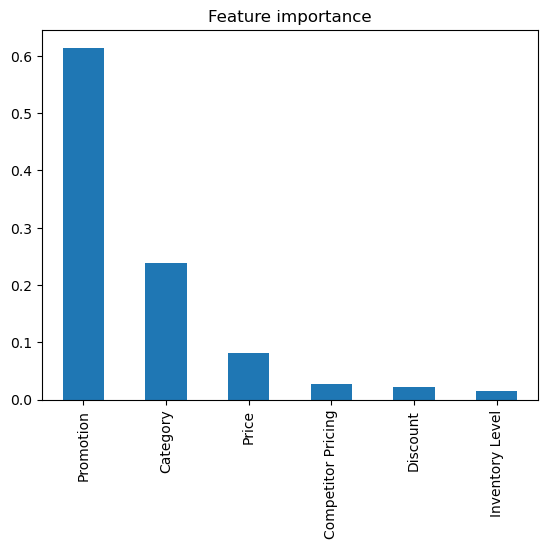

In [35]:
feature_importance.plot(kind='bar', title='Feature importance')

In [36]:
with open("label_encoders.pkl","wb") as f:
    pickle.dump(label_encoders, f)

In [37]:
with open("xgboost_demand_model.pkl","wb") as f:
    pickle.dump(best_model,f)